# Modeling Customer Trade-offs with a Choice Model

## Scenario
A meal kit delivery company surveyed prospective customers on plan preferences.
Respondents chose among three plan alternatives across multiple tasks.
Your goal: fit a choice model, identify which features drive selection,
and build a price sensitivity chart to support product decisions.

## Data: `mealkit_choice_tasks.csv`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('Exercise_Data')
if not DATA_DIR.exists():
    DATA_DIR = Path('/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Exercises/Udacity Exercises Redone/')

CHOICE_PATH = DATA_DIR / 'mealkit_choice_tasks.csv'
PLANS_PATH  = DATA_DIR / 'mealkit_plans.csv'
ADOPT_PATH  = DATA_DIR / 'mealkit_trial_adoption.csv'
SURVEY_PATH = DATA_DIR / 'mealkit_survey.csv'
MMM_PATH    = DATA_DIR / 'mealkit_marketing_weekly.csv'

df = pd.read_csv(CHOICE_PATH)
print(f"Rows: {df.shape[0]:,}  |  Respondents: {df['respondent_id'].nunique()}")
print(f"Tasks per respondent: {df['task_id'].nunique()}  |  Alternatives: {df['alternative'].nunique()}")
df.head(6)

Rows: 14,400  |  Respondents: 600
Tasks per respondent: 8  |  Alternatives: 3


,respondent_id,task_id,alternative,meals_per_week,cuisine_variety,dietary_options,live_cooking_class,servings,price_per_week,chosen
0,1,1,A,2,premium,yes,no,2,110,0
1,1,1,B,2,premium,no,no,2,110,0
2,1,1,C,6,premium,yes,yes,2,30,1
3,1,2,A,6,premium,no,yes,2,65,1
4,1,2,B,4,standard,no,yes,4,30,0
5,1,2,C,6,premium,no,yes,1,85,0


## Step 1: Encode Categorical Features

In [3]:
from sklearn.linear_model import LogisticRegression

df_enc = pd.get_dummies(df,
    columns=['cuisine_variety','dietary_options','live_cooking_class'],
    drop_first=False)

df_enc = df_enc.drop(columns=[
    'cuisine_variety_standard','dietary_options_no','live_cooking_class_no'])

feat_cols = ['price_per_week','meals_per_week','servings',
             'cuisine_variety_premium','dietary_options_yes','live_cooking_class_yes']

X = df_enc[feat_cols].astype(float)
y = df_enc['chosen']
print(f"Feature matrix: {X.shape}  |  Outcome: chosen (0/1)")

Feature matrix: (14400, 6)  |  Outcome: chosen (0/1)


## Step 2: Fit the Choice Model

In [4]:
# No feature scaling: preserves interpretability in original units
# No train-test split: we extract preference coefficients, not prediction accuracy
# Keep L2 regularization (default): helps convergence with binary outcomes
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X, y)

coefs = pd.Series(model.coef_[0], index=feat_cols)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
print("Part-worth utilities (sorted by absolute magnitude):")
print(coefs_sorted.round(4))

Part-worth utilities (sorted by absolute magnitude):
dietary_options_yes        0.6781
live_cooking_class_yes     0.3912
cuisine_variety_premium    0.3578
meals_per_week             0.0706
servings                   0.0646
price_per_week            -0.0352
dtype: float64


## Step 3: Coefficient Bar Chart

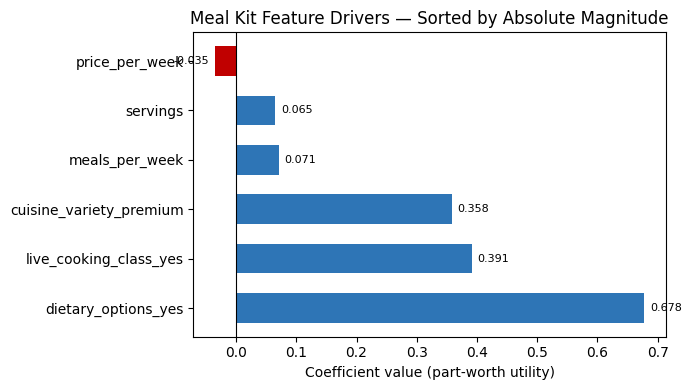

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2E75B6' if c > 0 else '#C00000' for c in coefs_sorted.values]
ax.barh(coefs_sorted.index, coefs_sorted.values, color=colors, height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient value (part-worth utility)')
ax.set_title('Meal Kit Feature Drivers — Sorted by Absolute Magnitude')
for bar, c in zip(ax.patches, coefs_sorted.values):
    ax.text(c + (0.01 if c >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{c:.3f}', va='center', ha='left' if c >= 0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

## Step 4: Price Sensitivity Chart

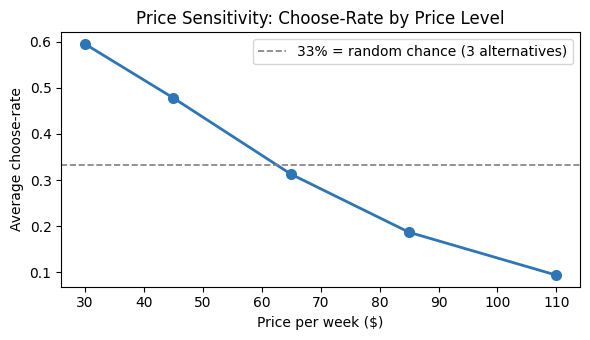

   price_per_week  choose_rate
0              30     0.595197
1              45     0.478014
2              65     0.312544
3              85     0.186806
4             110     0.093839


In [6]:
ps = (df.groupby('price_per_week')['chosen']
       .mean().reset_index()
       .rename(columns={'chosen':'choose_rate'}))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ps['price_per_week'], ps['choose_rate'], 'o-', color='#2E75B6', linewidth=2, markersize=7)
ax.axhline(0.333, color='gray', linestyle='--', linewidth=1.2, label='33% = random chance (3 alternatives)')
ax.set_xlabel('Price per week ($)'); ax.set_ylabel('Average choose-rate')
ax.set_title('Price Sensitivity: Choose-Rate by Price Level')
ax.legend(); plt.tight_layout(); plt.show()
print(ps)

## Reflection

**Top 3 feature drivers (by absolute coefficient magnitude):**

1. `dietary_options_yes` (+0.678): Dietary accommodation (vegetarian, vegan, gluten-free)
   is the strongest selection driver. Plans with dietary options are substantially
   more likely to be chosen, all else equal.

2. `live_cooking_class_yes` (+0.391): Including a live cooking class add-on is the
   second strongest positive driver. Customers perceive clear value in the interactive
   learning component beyond the meal kit itself.

3. `cuisine_variety_premium` (+0.358): Premium cuisine variety (chef-quality ingredients)
   is a meaningful positive driver, though slightly lower leverage than live classes.

**Price signal:** Choose-rate falls from ~60% at $30/week to under 10% at $110/week,
with the steepest decline between $45 and $85. The $65 tier sits near the random-chance
threshold, indicating high price sensitivity above this level.
